In [1]:
import torch
import sys
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
Platform: Linux-5.15.167.4-microsoft-standard-WSL2-x86_64-with-glibc2.35
PyTorch: 2.1.2+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import torch
import detectron2
import pytorch3d

print("torch:", torch.__version__)
print("detectron2 imported successfully")
print("pytorch3d imported successfully")

torch: 2.1.2+cu121
detectron2 imported successfully
pytorch3d imported successfully


In [3]:
from pathlib import Path

BASE_DIR = Path.home() / "Assign_6"
MESHRCNN_DIR = BASE_DIR / "meshrcnn"

IMG_DIR = BASE_DIR / "input_images"
OUT_DIR = BASE_DIR / "outputs"
RENDER_DIR = BASE_DIR / "renders"

IMG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
RENDER_DIR.mkdir(parents=True, exist_ok=True)

print("Base:", BASE_DIR)
print("Mesh R-CNN:", MESHRCNN_DIR)
print("Images:", IMG_DIR)
print("Outputs:", OUT_DIR)
print("Renders:", RENDER_DIR)

Base: /home/mad03633/Assign_6
Mesh R-CNN: /home/mad03633/Assign_6/meshrcnn
Images: /home/mad03633/Assign_6/input_images
Outputs: /home/mad03633/Assign_6/outputs
Renders: /home/mad03633/Assign_6/renders


In [27]:
# Image paths
image_paths = {
    "chair_pix3d": IMG_DIR / "chair_2.jpg",
    "sofa_pix3d": IMG_DIR / "sofa_2.jpg",
    "car_ood": IMG_DIR / "car_2.jpg",
}

for name, path in image_paths.items():
    print(name, "->", path, "| exists:", path.exists())

chair_pix3d -> /home/mad03633/Assign_6/input_images/chair_2.jpg | exists: True
sofa_pix3d -> /home/mad03633/Assign_6/input_images/sofa_2.jpg | exists: True
car_ood -> /home/mad03633/Assign_6/input_images/car_2.jpg | exists: True


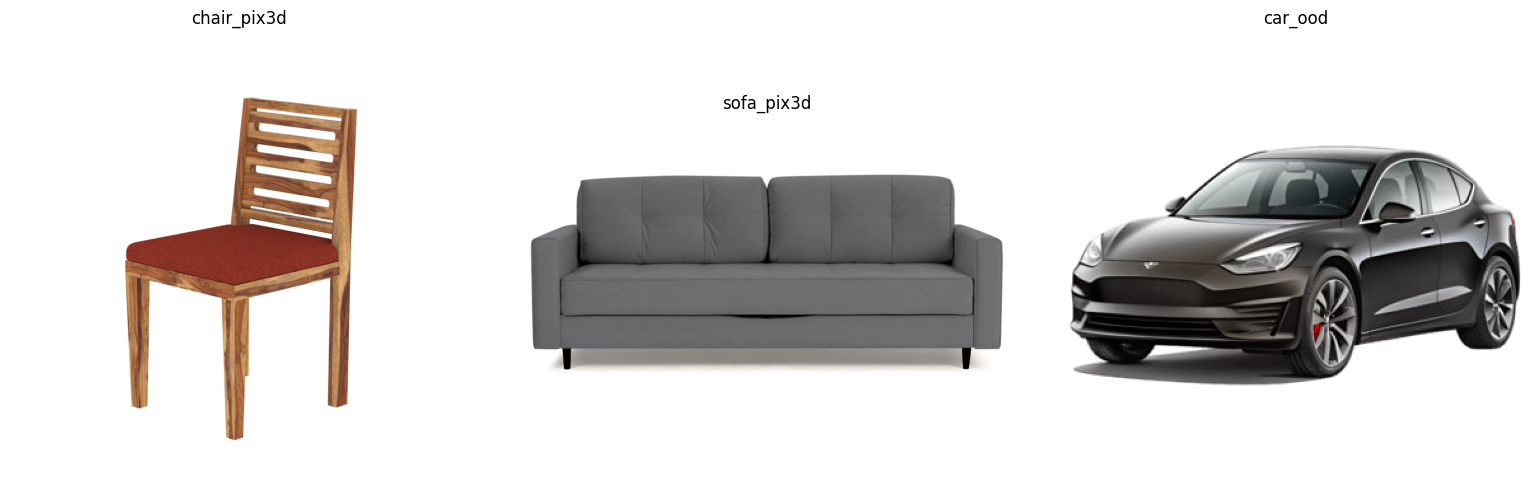

In [28]:
# Display images
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(16, 5))

for i, (name, path) in enumerate(image_paths.items(), 1):
    plt.subplot(1, 3, i)
    
    if path.exists():
        img = Image.open(path).convert("RGB")
        plt.imshow(img)
        plt.title(name)
    else:
        plt.text(0.5, 0.5, f"{name}\nnot found", ha="center", va="center")
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Run Mesh R-CNN demo for chair
import sys

%cd /home/mad03633/Assign_6/meshrcnn

!PYTHONPATH=/home/mad03633/Assign_6/meshrcnn {sys.executable} demo/demo.py \
    --config-file configs/pix3d/meshrcnn_R50_FPN.yaml \
    --input /home/mad03633/Assign_6/input_images/chair_2.jpg \
    --output /home/mad03633/Assign_6/outputs/chair_2 \
    --onlyhighest \
    MODEL.WEIGHTS meshrcnn://meshrcnn_R50.pth

/home/mad03633/Assign_6/meshrcnn


/home/mad03633/Assign_6/graphics/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


[04/30 15:50:50 demo]: Arguments: Namespace(config_file='configs/pix3d/meshrcnn_R50_FPN.yaml', input='/home/mad03633/Assign_6/input_images/chair_2.jpg', output='/home/mad03633/Assign_6/outputs/chair_2', focal_length=20.0, onlyhighest=True, opts=['MODEL.WEIGHTS', 'meshrcnn://meshrcnn_R50.pth'])
/home/mad03633/Assign_6/graphics/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[04/30 15:50:56 demo]: Predictions saved in /home/mad03633/Assign_6/outputs/chair_2/chair_2


In [8]:
# Run Mesh R-CNN demo for sofa
import sys

%cd /home/mad03633/Assign_6/meshrcnn

!PYTHONPATH=/home/mad03633/Assign_6/meshrcnn {sys.executable} demo/demo.py \
    --config-file configs/pix3d/meshrcnn_R50_FPN.yaml \
    --input /home/mad03633/Assign_6/input_images/sofa_2.jpg \
    --output /home/mad03633/Assign_6/outputs/sofa_2 \
    --onlyhighest \
    MODEL.WEIGHTS meshrcnn://meshrcnn_R50.pth

/home/mad03633/Assign_6/meshrcnn
[04/30 15:51:11 demo]: Arguments: Namespace(config_file='configs/pix3d/meshrcnn_R50_FPN.yaml', input='/home/mad03633/Assign_6/input_images/sofa_2.jpg', output='/home/mad03633/Assign_6/outputs/sofa_2', focal_length=20.0, onlyhighest=True, opts=['MODEL.WEIGHTS', 'meshrcnn://meshrcnn_R50.pth'])
/home/mad03633/Assign_6/graphics/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[04/30 15:51:15 demo]: Predictions saved in /home/mad03633/Assign_6/outputs/sofa_2/sofa_2


In [9]:
# Run Mesh R-CNN demo for car
import sys

%cd /home/mad03633/Assign_6/meshrcnn

!PYTHONPATH=/home/mad03633/Assign_6/meshrcnn {sys.executable} demo/demo.py \
    --config-file configs/pix3d/meshrcnn_R50_FPN.yaml \
    --input /home/mad03633/Assign_6/input_images/car_2.jpg \
    --output /home/mad03633/Assign_6/outputs/car_2 \
    MODEL.WEIGHTS meshrcnn://meshrcnn_R50.pth

/home/mad03633/Assign_6/meshrcnn


/home/mad03633/Assign_6/graphics/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


[04/30 15:51:47 demo]: Arguments: Namespace(config_file='configs/pix3d/meshrcnn_R50_FPN.yaml', input='/home/mad03633/Assign_6/input_images/car_2.jpg', output='/home/mad03633/Assign_6/outputs/car_2', focal_length=20.0, onlyhighest=False, opts=['MODEL.WEIGHTS', 'meshrcnn://meshrcnn_R50.pth'])
/home/mad03633/Assign_6/graphics/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[04/30 15:51:52 demo]: Predictions saved in /home/mad03633/Assign_6/outputs/car_2/car_2


In [10]:
from pathlib import Path


# Results overview
for folder_name in ["chair_2", "sofa_2", "car_2"]:
    folder = OUT_DIR / folder_name
    
    print("\n" + "=" * 60)
    print(folder_name)
    print("=" * 60)
    
    if folder.exists():
        files = sorted(folder.rglob("*"))
        if len(files) == 0:
            print("Folder is empty")
        else:
            for file in files:
                print(file.relative_to(BASE_DIR))
    else:
        print("Folder does not exist:", folder)


chair_2
outputs/chair_2/chair_2
outputs/chair_2/chair_2/0_mask_chair_1.000.png
outputs/chair_2/chair_2/0_mesh_chair_1.000.obj

sofa_2
outputs/sofa_2/sofa_2
outputs/sofa_2/sofa_2/0_mask_sofa_1.000.png
outputs/sofa_2/sofa_2/0_mesh_sofa_1.000.obj

car_2
outputs/car_2/car_2
outputs/car_2/car_2/0_mask_table_0.875.png
outputs/car_2/car_2/0_mesh_table_0.875.obj
outputs/car_2/car_2/1_mask_bed_0.567.png
outputs/car_2/car_2/1_mesh_bed_0.567.obj
outputs/car_2/car_2/2_mask_chair_0.520.png
outputs/car_2/car_2/2_mesh_chair_0.520.obj
outputs/car_2/car_2/3_mask_sofa_0.159.png
outputs/car_2/car_2/3_mesh_sofa_0.159.obj


In [11]:
# Search for OBJ files in outputs
from pathlib import Path


def find_obj_files(folder):
    folder = Path(folder)
    return sorted(folder.rglob("*.obj"))

mesh_files = {}

for name in ["chair_2", "sofa_2", "car_2"]:
    objs = find_obj_files(OUT_DIR / name)
    mesh_files[name] = objs
    
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    if len(objs) == 0:
        print("No OBJ files found")
    else:
        for obj in objs:
            print(obj.relative_to(BASE_DIR))


chair_2
outputs/chair_2/chair_2/0_mesh_chair_1.000.obj

sofa_2
outputs/sofa_2/sofa_2/0_mesh_sofa_1.000.obj

car_2
outputs/car_2/car_2/0_mesh_table_0.875.obj
outputs/car_2/car_2/1_mesh_bed_0.567.obj
outputs/car_2/car_2/2_mesh_chair_0.520.obj
outputs/car_2/car_2/3_mesh_sofa_0.159.obj


In [12]:
import re
import pandas as pd

# Extract confidence score from filename
def extract_confidence_from_filename(path):
    """
    Tries to extract confidence score from filename.
    Example:
    0_mesh_sofa_0.887.obj -> 0.887
    """
    name = Path(path).stem
    numbers = re.findall(r"\d+\.\d+", name)
    
    if len(numbers) == 0:
        return None
    
    return float(numbers[-1])

# Extract predicted class from filename
def extract_class_from_filename(path):
    """
    Example:
    0_mesh_chair_1.000.obj -> chair
    1_mesh_bed_0.749.obj -> bed
    """
    name = Path(path).stem
    
    # remove index and prefix
    # 0_mesh_chair_1.000 -> chair
    parts = name.split("_")
    
    if len(parts) >= 4:
        return "_".join(parts[2:-1])
    
    return None

records = []

for image_name, objs in mesh_files.items():
    for obj in objs:
        records.append({
            "input_image": image_name,
            "predicted_class": extract_class_from_filename(obj),
            "mesh_file": obj.name,
            "full_path": str(obj),
            "confidence_score": extract_confidence_from_filename(obj)
        })

df_meshes = pd.DataFrame(records)

print("Rows:", len(df_meshes))
display(df_meshes)

Rows: 6


,input_image,predicted_class,mesh_file,full_path,confidence_score
0,chair_2,chair,0_mesh_chair_1.000.obj,/home/mad03633/Assign_6/outputs/chair_2/chair_...,1.000
1,sofa_2,sofa,0_mesh_sofa_1.000.obj,/home/mad03633/Assign_6/outputs/sofa_2/sofa_2/...,1.000
2,car_2,table,0_mesh_table_0.875.obj,/home/mad03633/Assign_6/outputs/car_2/car_2/0_...,0.875
3,car_2,bed,1_mesh_bed_0.567.obj,/home/mad03633/Assign_6/outputs/car_2/car_2/1_...,0.567
4,car_2,chair,2_mesh_chair_0.520.obj,/home/mad03633/Assign_6/outputs/car_2/car_2/2_...,0.520
5,car_2,sofa,3_mesh_sofa_0.159.obj,/home/mad03633/Assign_6/outputs/car_2/car_2/3_...,0.159


In [13]:
# Top-1 mesh per image based on confidence score
df_top = (
    df_meshes
    .sort_values(["input_image", "confidence_score"], ascending=[True, False])
    .groupby("input_image")
    .head(1)
    .reset_index(drop=True)
)

display(df_top)

,input_image,predicted_class,mesh_file,full_path,confidence_score
0,car_2,table,0_mesh_table_0.875.obj,/home/mad03633/Assign_6/outputs/car_2/car_2/0_...,0.875
1,chair_2,chair,0_mesh_chair_1.000.obj,/home/mad03633/Assign_6/outputs/chair_2/chair_...,1.000
2,sofa_2,sofa,0_mesh_sofa_1.000.obj,/home/mad03633/Assign_6/outputs/sofa_2/sofa_2/...,1.000


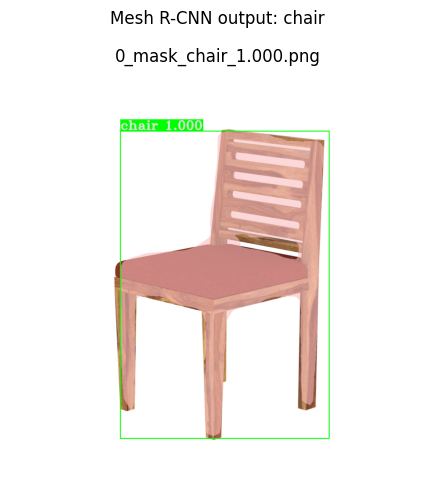

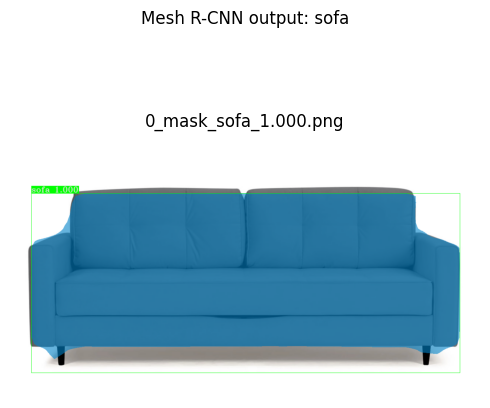

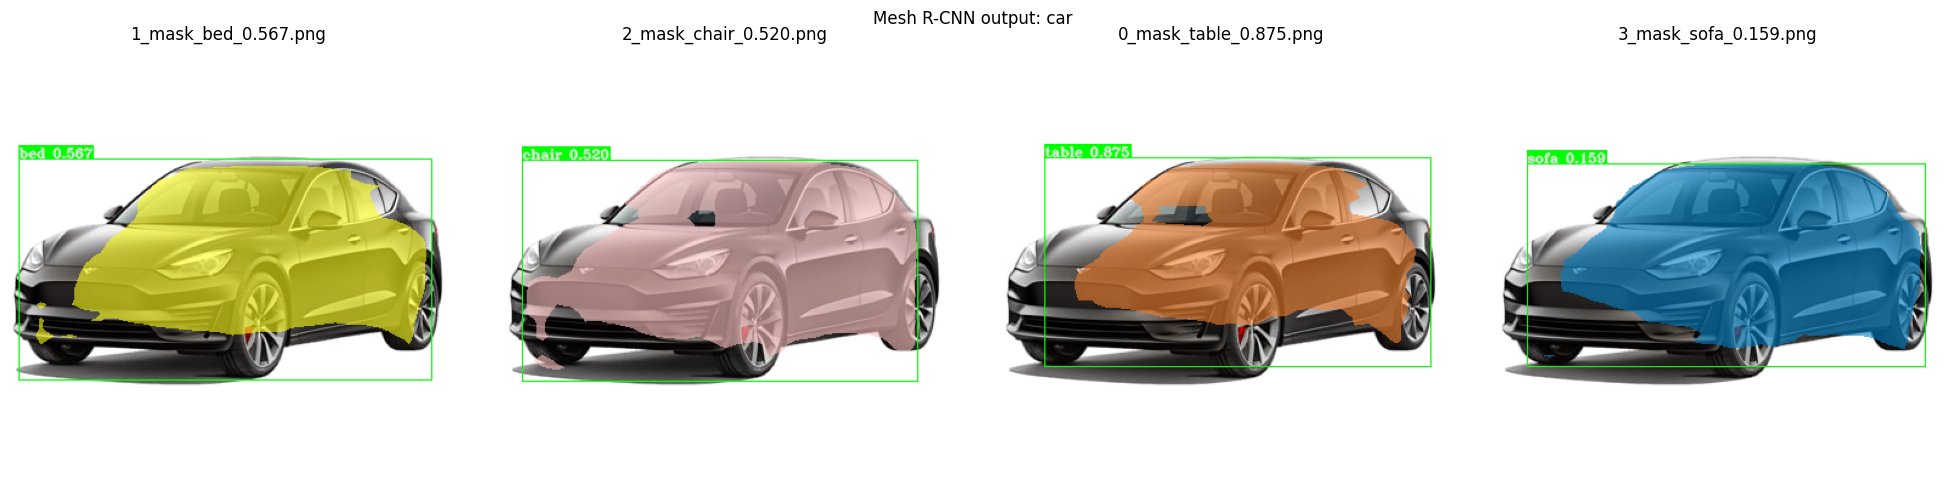

In [14]:
import matplotlib.pyplot as plt
from PIL import Image


# Function to display output images
def show_output_images(folder, title):
    folder = Path(folder)
    image_files = (
        list(folder.rglob("*.png")) +
        list(folder.rglob("*.jpg")) +
        list(folder.rglob("*.jpeg"))
    )
    
    if len(image_files) == 0:
        print("No output images found in:", folder)
        return
    
    plt.figure(figsize=(5 * min(len(image_files), 4), 5))
    
    for i, img_path in enumerate(image_files[:4], 1):
        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, min(len(image_files), 4), i)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_output_images(OUT_DIR / "chair_2", "Mesh R-CNN output: chair")
show_output_images(OUT_DIR / "sofa_2", "Mesh R-CNN output: sofa")
show_output_images(OUT_DIR / "car_2", "Mesh R-CNN output: car")

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [16]:
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import TexturesVertex


# Function of mesh loading for rendering
def load_mesh_for_rendering(obj_path):
    obj_path = Path(obj_path)
    
    verts, faces_idx, _ = load_obj(str(obj_path))
    faces = faces_idx.verts_idx
    
    # Center and normalize mesh
    center = verts.mean(dim=0)
    verts = verts - center
    
    scale = verts.abs().max()
    if scale > 0:
        verts = verts / scale
    
    verts = verts.to(device)
    faces = faces.to(device)
    
    # White vertex texture
    verts_rgb = torch.ones_like(verts)[None].to(device)
    textures = TexturesVertex(verts_features=verts_rgb)
    
    mesh = Meshes(
        verts=[verts],
        faces=[faces],
        textures=textures
    )
    
    return mesh

In [17]:
from pytorch3d.renderer.cameras import FoVPerspectiveCameras
from pytorch3d.renderer import (
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    HardPhongShader,
    PointLights,
    look_at_view_transform
)


# 3-view mesh rendering function
def render_mesh_views(
    obj_path,
    save_prefix,
    distance=3.0,
    elevations=(10, 20, 30),
    azimuths=(-60, 0, 60),
    image_size=512
):
    obj_path = Path(obj_path)
    mesh = load_mesh_for_rendering(obj_path)
    
    raster_settings = RasterizationSettings(
        image_size=image_size,
        blur_radius=0.0,
        faces_per_pixel=1,
    )
    
    lights = PointLights(
        device=device,
        location=((2.0, 2.0, 2.0),)
    )
    
    rendered_images = []
    
    for idx, (elev, azim) in enumerate(zip(elevations, azimuths), 1):
        R, T = look_at_view_transform(
            dist=distance,
            elev=elev,
            azim=azim,
            device=device
        )
        
        cameras = FoVPerspectiveCameras(device=device, R=R, T=T)
        
        renderer = MeshRenderer(
            rasterizer=MeshRasterizer(
                cameras=cameras,
                raster_settings=raster_settings
            ),
            shader=HardPhongShader(
                device=device,
                cameras=cameras,
                lights=lights
            )
        )
        
        image = renderer(mesh)
        image_np = image[0, ..., :3].detach().cpu().numpy()
        rendered_images.append((elev, azim, image_np))
        
        save_path = RENDER_DIR / f"{save_prefix}_view{idx}_elev{elev}_azim{azim}.png"
        plt.imsave(save_path, image_np)
        print("Saved:", save_path)
    
    plt.figure(figsize=(15, 5))
    
    for i, (elev, azim, img) in enumerate(rendered_images, 1):
        plt.subplot(1, len(rendered_images), i)
        plt.imshow(img)
        plt.title(f"elev={elev}, azim={azim}")
        plt.axis("off")
    
    plt.suptitle(save_prefix)
    plt.tight_layout()
    plt.show()

In [19]:
# Select the main mesh for each image
def get_top_mesh(input_image_name):
    subset = df_meshes[df_meshes["input_image"] == input_image_name].copy()
    
    if len(subset) == 0:
        return None
    
    subset = subset.sort_values("confidence_score", ascending=False)
    return Path(subset.iloc[0]["full_path"])

chair_mesh = get_top_mesh("chair_2")
sofa_mesh = get_top_mesh("sofa_2")
car_mesh = get_top_mesh("car_2")

print("Chair mesh:", chair_mesh)
print("Sofa mesh:", sofa_mesh)
print("Car mesh:", car_mesh)

Chair mesh: /home/mad03633/Assign_6/outputs/chair_2/chair_2/0_mesh_chair_1.000.obj
Sofa mesh: /home/mad03633/Assign_6/outputs/sofa_2/sofa_2/0_mesh_sofa_1.000.obj
Car mesh: /home/mad03633/Assign_6/outputs/car_2/car_2/0_mesh_table_0.875.obj


/home/mad03633/Assign_6/graphics/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:544: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


Saved: /home/mad03633/Assign_6/renders/chair_view1_elev10_azim-60.png
Saved: /home/mad03633/Assign_6/renders/chair_view2_elev20_azim0.png
Saved: /home/mad03633/Assign_6/renders/chair_view3_elev30_azim60.png


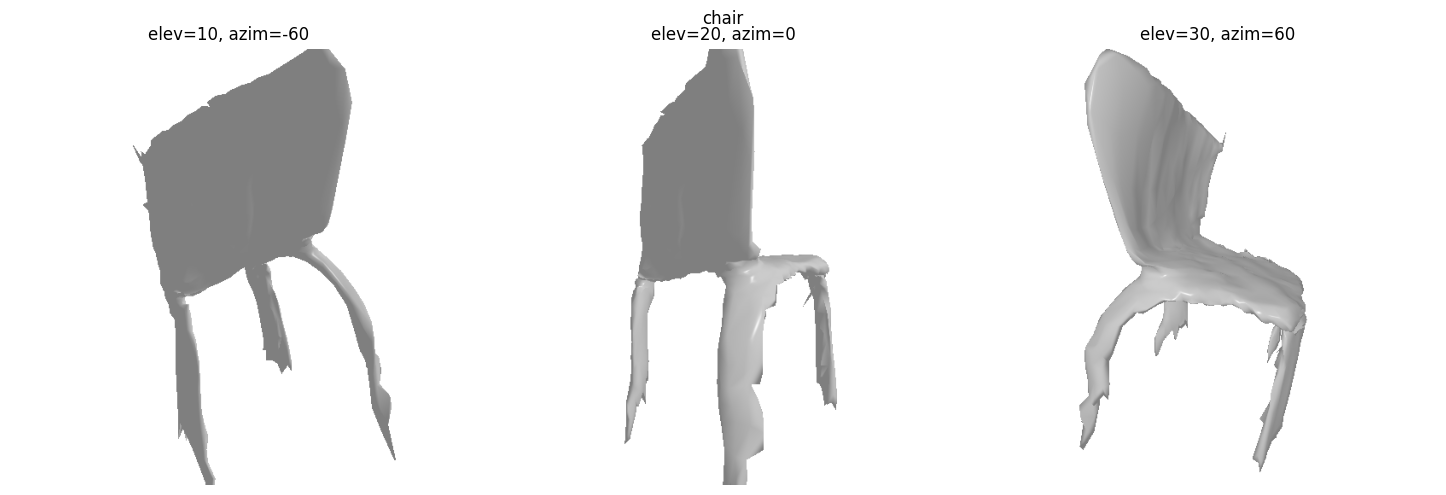

In [20]:
# Render chair mesh views
if chair_mesh is not None:
    render_mesh_views(
        obj_path=chair_mesh,
        save_prefix="chair",
        distance=2.0,
        elevations=(10, 20, 30),
        azimuths=(-60, 0, 60)
    )
else:
    print("No mesh found for chair")

Saved: /home/mad03633/Assign_6/renders/sofa_view1_elev10_azim-60.png
Saved: /home/mad03633/Assign_6/renders/sofa_view2_elev20_azim0.png
Saved: /home/mad03633/Assign_6/renders/sofa_view3_elev30_azim60.png


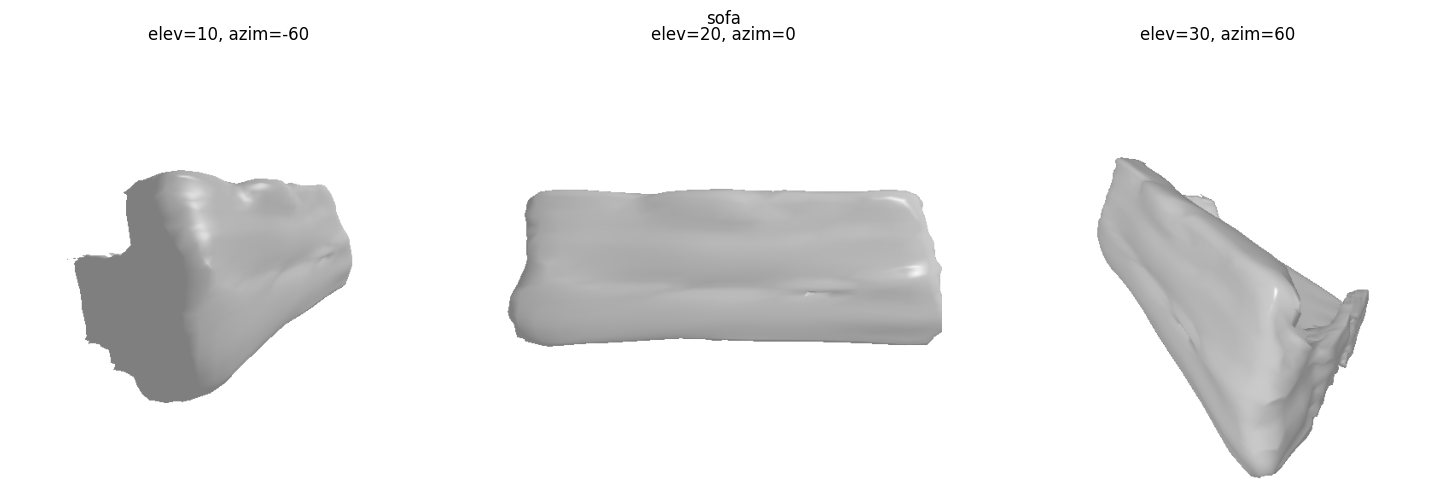

In [21]:
# Render sofa mesh views
if sofa_mesh is not None:
    render_mesh_views(
        obj_path=sofa_mesh,
        save_prefix="sofa",
        distance=2.0,
        elevations=(10, 20, 30),
        azimuths=(-60, 0, 60)
    )
else:
    print("No mesh found for sofa")

Saved: /home/mad03633/Assign_6/renders/car_view1_elev10_azim-60.png
Saved: /home/mad03633/Assign_6/renders/car_view2_elev20_azim0.png
Saved: /home/mad03633/Assign_6/renders/car_view3_elev30_azim60.png


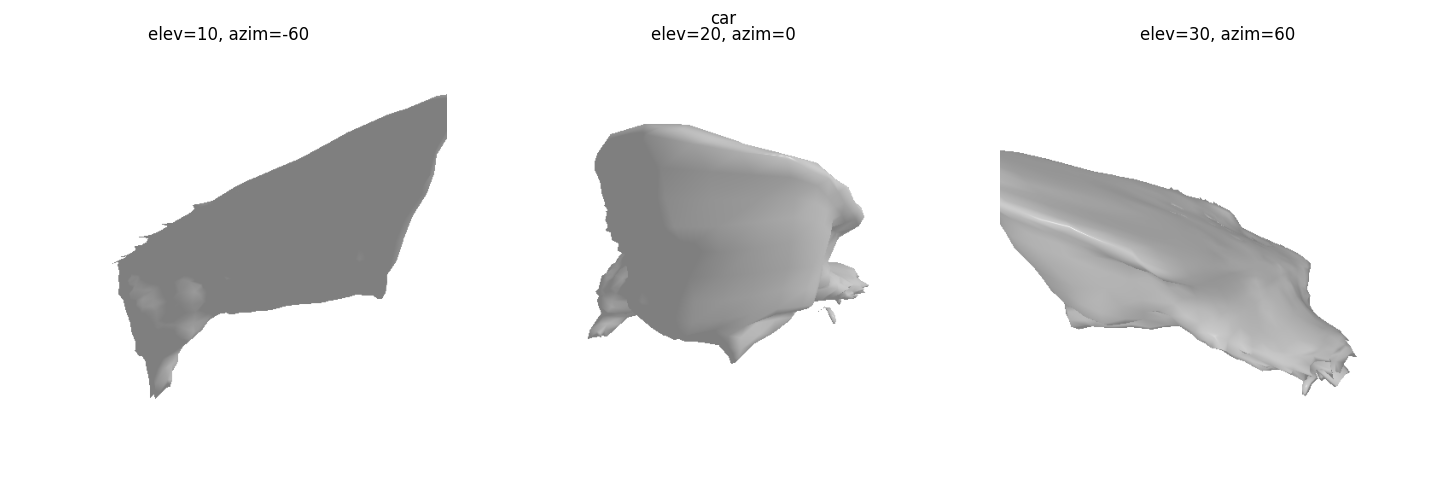

In [22]:
# Render car mesh views
if car_mesh is not None:
    render_mesh_views(
        obj_path=car_mesh,
        save_prefix="car",
        distance=2.0,
        elevations=(10, 20, 30),
        azimuths=(-60, 0, 60)
    )
else:
    print("No mesh found for car")

In [25]:
car_predictions = (
    df_meshes[df_meshes["input_image"] == "car_2"]
    .sort_values("confidence_score", ascending=False)
    .reset_index(drop=True)
)

display(car_predictions[["predicted_class", "confidence_score", "mesh_file"]].head(10))

,predicted_class,confidence_score,mesh_file
0,table,0.875,0_mesh_table_0.875.obj
1,bed,0.567,1_mesh_bed_0.567.obj
2,chair,0.520,2_mesh_chair_0.520.obj
3,sofa,0.159,3_mesh_sofa_0.159.obj


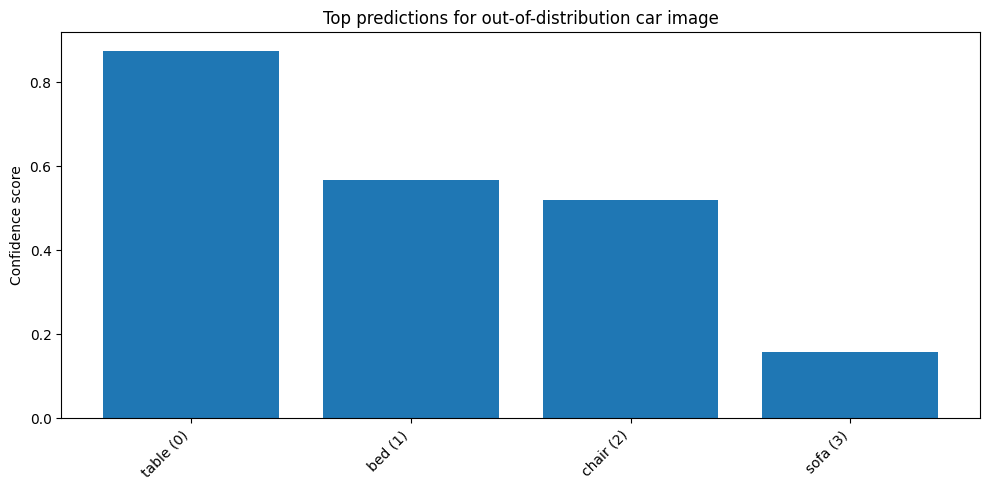

In [26]:
top_car = car_predictions.head(10)

plt.figure(figsize=(10, 5))
plt.bar(
    top_car["predicted_class"] + " (" + top_car.index.astype(str) + ")",
    top_car["confidence_score"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Confidence score")
plt.title("Top predictions for out-of-distribution car image")
plt.tight_layout()
plt.show()